In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
# The raw transaction data. Use the local file, or the hosted copy once uploaded.
csv_path_1 = "moneycraft_accounts.csv"
csv_path_2 = "moneycraft_closure_reasons.csv"
csv_path_3 = "moneycraft_marketing_spend.csv"

mc_accounts_df = pd.read_csv(csv_path_1)
mc_closure_reasons_df = pd.read_csv(csv_path_2)
mc_marketing_spend_df = pd.read_csv(csv_path_3)
print('Data loaded!')

Data loaded!


In [94]:
mc_accounts_df.head()

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo
0,1,2022-01,Comparison Site,Scotland,25-34,Classic,0,False
1,2,2022-01,Online,London,55-64,Silver,11,False
2,3,2022-01,Branch,South East,25-34,Platinum,28,False
3,4,2022-01,Referral,London,25-34,Silver,0,True
4,5,2022-01,Comparison Site,South East,35-44,Silver,11,False


In [95]:
mc_accounts_df

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo
0,1,2022-01,Comparison Site,Scotland,25-34,Classic,0,False
1,2,2022-01,Online,London,55-64,Silver,11,False
2,3,2022-01,Branch,South East,25-34,Platinum,28,False
3,4,2022-01,Referral,London,25-34,Silver,0,True
4,5,2022-01,Comparison Site,South East,35-44,Silver,11,False
...,...,...,...,...,...,...,...,...
179013,15728,2024-12,Outbound,Midlands,35-44,Silver,0,True
179014,15729,2024-12,Comparison Site,Midlands,25-34,Classic,0,True
179015,15730,2024-12,Referral,London,25-34,Gold,18,False
179016,15731,2024-12,Online,South East,55-64,Platinum,28,False


In [96]:
mc_closure_reasons_df.head()

,customer_id,close_month,reason_code
0,10755,2024-05,Switched provider
1,7582,2025-01,Unhappy with perks
2,2162,2024-11,Fees too high
3,3016,2023-02,Switched provider
4,564,2022-07,Poor service


In [97]:
mc_marketing_spend_df.head()

,month,channel,spend_gbp
0,2022-01,Branch,7310.0
1,2022-01,Broker/IFA,4014.0
2,2022-01,Comparison Site,3162.0
3,2022-01,Online,3945.0
4,2022-01,Outbound,4899.0


In [98]:
mc_marketing_total_spend = mc_marketing_spend_df.groupby("channel")["spend_gbp"].sum()
#mc_marketing_total_spend.sort_values('spend_gbp', ascending=False)
mc_marketing_total_spend

channel
Branch             377567.0
Broker/IFA         195020.0
Comparison Site    182406.0
Online             269322.0
Outbound           239264.0
Referral           112021.0
Name: spend_gbp, dtype: float64

In [99]:
#mc_marketing_total_spend.to_csv("moneycraft_")

In [100]:
mc_marketing_spend_df.sum()

month        2022-012022-012022-012022-012022-012022-012022...
channel      BranchBroker/IFAComparison SiteOnlineOutboundR...
spend_gbp                                            1375600.0
dtype: object

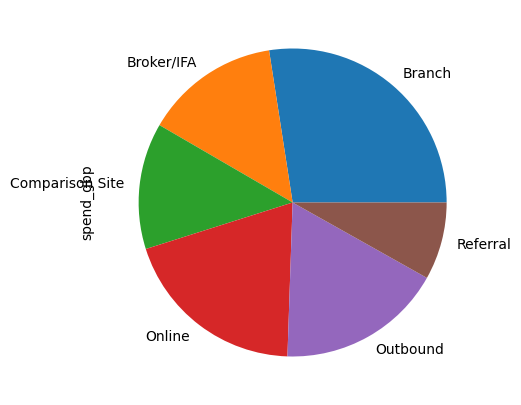

In [101]:
plot = mc_marketing_total_spend.plot.pie(y="spend_gbp", figsize=(5, 5))
#plot.title("this")

# SCV

In [102]:
mc_accounts_df['month'] = pd.PeriodIndex(mc_accounts_df['month'], freq='M')
mc_accounts_df['month'].head()

0    2022-01
1    2022-01
2    2022-01
3    2022-01
4    2022-01
Name: month, dtype: period[M]

In [103]:
from typing import AsyncGenerator
grouped = mc_accounts_df.groupby('customer_id')

# .cumcount() - Number each item in each group from 0 to the length of that group - 1
mc_accounts_df['lifecycle_month'] = mc_accounts_df.groupby('customer_id').cumcount()

signup_month = grouped['month'].min()   # First month
last_active = grouped['month'].max()   # last month
tenure_months = grouped['month'].count()    # total tenure
channel = grouped['acquisition_channel'].first()
age_band = grouped['age_band'].first()
region = grouped['region'].first()
first_plan = grouped['account_tier'].first()

month_7 = mc_accounts_df[mc_accounts_df['lifecycle_month'] == 6]
post_promo_first_plan = month_7.set_index('customer_id')['account_tier'] # first plan right after the promo

last_plan = grouped['account_tier'].last()
total_revenue = grouped['monthly_fee'].sum()
max_paid = grouped['monthly_fee'].max()
joined_on_promo = grouped['joined_on_promo'].first()
# ever_paid = grouped['monthly_fee' > 0]

In [104]:
scv = pd.DataFrame({
    'signup_month': signup_month,
    'last_active': last_active,
    'tenure_months': tenure_months,
    'channel': channel,
    'age_band': age_band,
    'region': region,
    'first_plan': first_plan,
    'post_promo_first_plan':post_promo_first_plan,
    'last_plan': last_plan,
    'total_revenue': total_revenue,
    'max_paid': max_paid,
    'joined_on_promo': joined_on_promo
    
})

scv['ever_paid'] = max_paid > 0
scv.head()

,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,post_promo_first_plan,last_plan,total_revenue,max_paid,joined_on_promo,ever_paid
customer_id,,,,,,,,,,,,,
1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,NaN,Classic,0,0,False,False
2,2022-01,2024-12,36,Online,55-64,London,Silver,Silver,Platinum,595,28,False,True
3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,Platinum,848,28,False,True
4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,Silver,330,11,True,True
5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,Classic,33,11,False,True


In [105]:
from typing_extensions import final
# Add churned flag
final_month = mc_accounts_df['month'].max()   # Last month in data
scv['churned'] = scv['last_active'] < final_month
scv.head()
# scv[['signup_month', 'last_active', 'tenure_months', 'churned']].head()

,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,post_promo_first_plan,last_plan,total_revenue,max_paid,joined_on_promo,ever_paid,churned
customer_id,,,,,,,,,,,,,,
1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,NaN,Classic,0,0,False,False,True
2,2022-01,2024-12,36,Online,55-64,London,Silver,Silver,Platinum,595,28,False,True,False
3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,Platinum,848,28,False,True,False
4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,Silver,330,11,True,True,False
5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,Classic,33,11,False,True,True


In [106]:
# Merging tables - main table with closure data
df_merged = pd.merge(scv, mc_closure_reasons_df, on='customer_id', how='left')
df_merged.head()

,customer_id,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,post_promo_first_plan,last_plan,total_revenue,max_paid,joined_on_promo,ever_paid,churned,close_month,reason_code
0,1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,NaN,Classic,0,0,False,False,True,2022-07,Switched provider
1,2,2022-01,2024-12,36,Online,55-64,London,Silver,Silver,Platinum,595,28,False,True,False,NaN,NaN
2,3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,Platinum,848,28,False,True,False,NaN,NaN
3,4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,Silver,330,11,True,True,False,NaN,NaN
4,5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,Classic,33,11,False,True,True,2022-11,Bereavement


In [107]:
#df_merged

# Promo Cohort analysis

People joining normally and promo

In [ ]:
survival_by_class = titanic.groupby('class')['survived'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(survival_by_class.index, survival_by_class.values)
plt.xlabel('Passenger Class')
plt.ylabel('Number of Survivors')
plt.title('Customer joining on promo')
plt.tight_layout()
plt.show()

In [301]:
promo_cohort = df_merged[df_merged['joined_on_promo'] == True].copy()
promo_cohort

,customer_id,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,post_promo_first_plan,last_plan,total_revenue,max_paid,joined_on_promo,ever_paid,churned,close_month,reason_code
3,4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,Silver,330,11,True,True,False,NaN,NaN
9,10,2022-01,2024-12,36,Broker/IFA,18-24,Scotland,Gold,Platinum,Platinum,840,28,True,True,False,NaN,NaN
10,11,2022-01,2022-08,8,Comparison Site,18-24,South East,Classic,Classic,Classic,0,0,True,False,True,2022-09,Switched provider
12,13,2022-01,2023-06,18,Comparison Site,25-34,London,Classic,Classic,Classic,0,0,True,False,True,2023-07,Switched provider
14,15,2022-01,2022-01,1,Branch,25-34,North,Silver,NaN,Silver,0,0,True,False,True,2022-02,Fees too high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15723,15724,2024-12,2024-12,1,Online,25-34,Wales & NI,Classic,NaN,Classic,0,0,True,False,False,NaN,NaN
15726,15727,2024-12,2024-12,1,Comparison Site,55-64,South East,Classic,NaN,Classic,0,0,True,False,False,NaN,NaN
15727,15728,2024-12,2024-12,1,Outbound,35-44,Midlands,Silver,NaN,Silver,0,0,True,False,False,NaN,NaN
15728,15729,2024-12,2024-12,1,Comparison Site,25-34,Midlands,Classic,NaN,Classic,0,0,True,False,False,NaN,NaN


In [302]:
print(f"There are {promo_cohort["customer_id"].count()} customers that joined on a promotion.")

There are 6146 customers that joined on a promotion.


#### Retention after promotion
Customers are retains after still being active after the 6-month fee waiver

In [303]:
promo_cohort_retention = promo_cohort[promo_cohort['tenure_months'] >= 7].copy()
promo_cohort_retention

,customer_id,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,post_promo_first_plan,last_plan,total_revenue,max_paid,joined_on_promo,ever_paid,churned,close_month,reason_code
3,4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,Silver,330,11,True,True,False,NaN,NaN
9,10,2022-01,2024-12,36,Broker/IFA,18-24,Scotland,Gold,Platinum,Platinum,840,28,True,True,False,NaN,NaN
10,11,2022-01,2022-08,8,Comparison Site,18-24,South East,Classic,Classic,Classic,0,0,True,False,True,2022-09,Switched provider
12,13,2022-01,2023-06,18,Comparison Site,25-34,London,Classic,Classic,Classic,0,0,True,False,True,2023-07,Switched provider
17,18,2022-01,2023-01,13,Comparison Site,45-54,London,Classic,Classic,Silver,55,11,True,True,True,2023-02,Poor service
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12264,12265,2024-06,2024-12,7,Comparison Site,45-54,North,Classic,Classic,Classic,0,0,True,False,False,NaN,NaN
12268,12269,2024-06,2024-12,7,Comparison Site,45-54,North,Gold,Gold,Gold,18,18,True,True,False,NaN,NaN
12273,12274,2024-06,2024-12,7,Online,55-64,Wales & NI,Classic,Classic,Classic,0,0,True,False,False,2025-01,Unknown
12274,12275,2024-06,2024-12,7,Outbound,25-34,Scotland,Platinum,Gold,Gold,18,18,True,True,False,NaN,NaN


In [304]:
print(f"There are {promo_cohort_retention["customer_id"].count()} customers that stayed after promotion ended.")

There are 3564 customers that stayed after promotion ended.


In [305]:
# Active after promotion (Tenure is 7 months or more)
promo_cohort['stayed_active'] = promo_cohort['tenure_months'] >= 7

active_count = promo_cohort['stayed_active'].value_counts()
active_percentages = promo_cohort['stayed_active'].value_counts(normalize=True) * 100

print("--- Promo Expiry Conversion Report ---")
print(f"Total Promo Signups: {len(promo_cohort)}")
print(f"Churned before/after promotion (<= 6 Months): {convert_paying_count[False]} ({convert_paying_percentages[False]:.1f}%)")
print(f"Did not churn (7+ Months): {convert_paying_count[True]} ({convert_paying_percentages[True]:.1f}%)")

--- Promo Expiry Conversion Report ---
Total Promo Signups: 6146
Churned before/after promotion (<= 6 Months): 2582 (42.0%)
Did not churn (7+ Months): 3564 (58.0%)


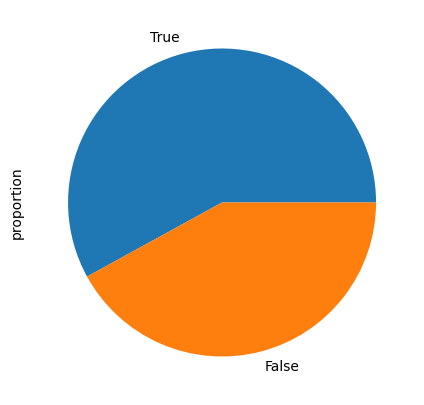

In [306]:
plot = active_percentages.plot.pie(y="active_percentages", figsize=(5, 5))

In [307]:
# default
promo_cohort['post_promo_status'] = 'Churned'

# active but stayed on Classic
promo_cohort.loc[
    (promo_cohort['tenure_months'] >= 7) & (promo_cohort['post_promo_first_plan'] == 'Classic'), 
    'post_promo_status'
] = 'Retained (Classic)'

# active and Paying (Active past month 6, and on a payed plan)
promo_cohort.loc[
    (promo_cohort['tenure_months'] >= 7) & (promo_cohort['post_promo_first_plan'].isin(['Silver', 'Gold', 'Platinum'])), 
    'post_promo_status'
] = 'Retained (Paid Plan)'

status_counts = promo_cohort['post_promo_status'].value_counts()
status_percentages = promo_cohort['post_promo_status'].value_counts(normalize=True) * 100

print("--- Post Promo Status ---")
for status, count in status_counts.items():
    pct = status_percentages[status]
    print(f"{status:} | Volume: {count:} | Share: {pct:.1f}%")

--- Post Promo Status ---
Retained (Paid Plan) | Volume: 2608 | Share: 42.4%
Churned | Volume: 2582 | Share: 42.0%
Retained (Classic) | Volume: 956 | Share: 15.6%


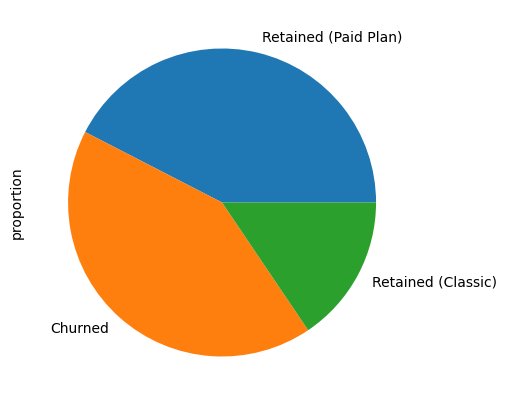

In [308]:
plot = status_percentages.plot.pie(y="status_percentages", figsize=(5, 5))

In [267]:
promo_cohort

,customer_id,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,post_promo_first_plan,last_plan,total_revenue,max_paid,joined_on_promo,ever_paid,churned,close_month,reason_code,stayed_active,post_promo_status
3,4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,Silver,330,11,True,True,False,NaN,NaN,True,Retained (Paid Plan)
9,10,2022-01,2024-12,36,Broker/IFA,18-24,Scotland,Gold,Platinum,Platinum,840,28,True,True,False,NaN,NaN,True,Retained (Paid Plan)
10,11,2022-01,2022-08,8,Comparison Site,18-24,South East,Classic,Classic,Classic,0,0,True,False,True,2022-09,Switched provider,True,Retained (Classic)
12,13,2022-01,2023-06,18,Comparison Site,25-34,London,Classic,Classic,Classic,0,0,True,False,True,2023-07,Switched provider,True,Retained (Classic)
14,15,2022-01,2022-01,1,Branch,25-34,North,Silver,NaN,Silver,0,0,True,False,True,2022-02,Fees too high,False,Churned
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15723,15724,2024-12,2024-12,1,Online,25-34,Wales & NI,Classic,NaN,Classic,0,0,True,False,False,NaN,NaN,False,Churned
15726,15727,2024-12,2024-12,1,Comparison Site,55-64,South East,Classic,NaN,Classic,0,0,True,False,False,NaN,NaN,False,Churned
15727,15728,2024-12,2024-12,1,Outbound,35-44,Midlands,Silver,NaN,Silver,0,0,True,False,False,NaN,NaN,False,Churned
15728,15729,2024-12,2024-12,1,Comparison Site,25-34,Midlands,Classic,NaN,Classic,0,0,True,False,False,NaN,NaN,False,Churned


#### Check customers who are upgrading/downgrading

In [309]:
tier_ranks = {'Classic': 1, 'Silver': 2, 'Gold': 3, 'Platinum': 4}

start_plan = promo_cohort_retention['first_plan'].map(tier_ranks)
month_7_plan = promo_cohort_retention['post_promo_first_plan'].map(tier_ranks)

In [310]:
promo_cohort_retention['post_promo_status_details'] = 'Churned'

# maintained
promo_cohort_retention.loc[
    (promo_cohort_retention['tenure_months'] >= 7) & (month_7_plan == start_plan), 
    'post_promo_status_details'
] = 'Retained (Maintained Tier)'

# downgraded
promo_cohort_retention.loc[
    (promo_cohort_retention['tenure_months'] >= 7) & (month_7_plan < start_plan), 
    'post_promo_status_details'
] = 'Retained (Downgraded Tier)'

# upgraded
promo_cohort_retention.loc[
    (promo_cohort_retention['tenure_months'] >= 7) & (month_7_plan > start_plan), 
    'post_promo_status_details'
] = 'Retained (Upgraded Tier)'

In [311]:
retention_status_counts = promo_cohort_retention['post_promo_status_details'].value_counts()
retention_status_percentages = promo_cohort_retention['post_promo_status_details'].value_counts(normalize=True) * 100

print("--- Detailed Post-Promo Migration Status ---")
for status, count in retention_status_counts.items():
    pct = retention_status_percentages[status]
    print(f"{status:<28} | Volume: {count:<5} | Share: {pct:.1f}%")

--- Detailed Post-Promo Migration Status ---
Retained (Maintained Tier)   | Volume: 2825  | Share: 79.3%
Retained (Upgraded Tier)     | Volume: 511   | Share: 14.3%
Retained (Downgraded Tier)   | Volume: 228   | Share: 6.4%


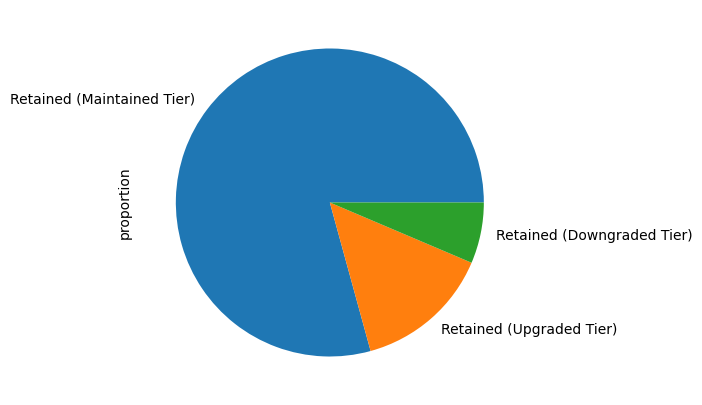

In [313]:
plot = retention_status_percentages.plot.pie(y="retention_status_percentages", figsize=(5, 5))

#### Focus Plan: Classic 
Is the £20 cinema voucher incentive worth it for the company?

#### How much it cost the company to get customers to join on promo classic & how many of those people stayed

In [293]:
promo_cohort_classic = promo_cohort[promo_cohort['first_plan'] == 'Classic']
promo_cohort_classic["customer_id"].count()

np.int64(2206)

In [296]:
# Cost of promo for classic
cost_of_classic_promo = promo_cohort_classic["customer_id"].count() * 20
cost_of_classic_promo

np.int64(44120)

In [276]:
#check again
promo_cohort_retention

,customer_id,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,post_promo_first_plan,last_plan,total_revenue,max_paid,joined_on_promo,ever_paid,churned,close_month,reason_code,stayed_active,post_promo_status,post_promo_status_details
3,4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,Silver,330,11,True,True,False,NaN,NaN,True,Retained (Paid Plan),Retained (Maintained Tier)
9,10,2022-01,2024-12,36,Broker/IFA,18-24,Scotland,Gold,Platinum,Platinum,840,28,True,True,False,NaN,NaN,True,Retained (Paid Plan),Retained (Upgraded Tier)
10,11,2022-01,2022-08,8,Comparison Site,18-24,South East,Classic,Classic,Classic,0,0,True,False,True,2022-09,Switched provider,True,Retained (Classic),Retained (Maintained Tier)
12,13,2022-01,2023-06,18,Comparison Site,25-34,London,Classic,Classic,Classic,0,0,True,False,True,2023-07,Switched provider,True,Retained (Classic),Retained (Maintained Tier)
17,18,2022-01,2023-01,13,Comparison Site,45-54,London,Classic,Classic,Silver,55,11,True,True,True,2023-02,Poor service,True,Retained (Classic),Retained (Maintained Tier)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12264,12265,2024-06,2024-12,7,Comparison Site,45-54,North,Classic,Classic,Classic,0,0,True,False,False,NaN,NaN,True,Retained (Classic),Retained (Maintained Tier)
12268,12269,2024-06,2024-12,7,Comparison Site,45-54,North,Gold,Gold,Gold,18,18,True,True,False,NaN,NaN,True,Retained (Paid Plan),Retained (Maintained Tier)
12273,12274,2024-06,2024-12,7,Online,55-64,Wales & NI,Classic,Classic,Classic,0,0,True,False,False,2025-01,Unknown,True,Retained (Classic),Retained (Maintained Tier)
12274,12275,2024-06,2024-12,7,Outbound,25-34,Scotland,Platinum,Gold,Gold,18,18,True,True,False,NaN,NaN,True,Retained (Paid Plan),Retained (Downgraded Tier)


In [281]:
# Get customers retained that started on classic
cohort_retention_classic = promo_cohort_retention[promo_cohort_retention['first_plan'] == 'Classic']

In [284]:
cohort_retention_classic["customer_id"].count()

np.int64(1057)

In [314]:
cohort_retention_classic

,customer_id,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,post_promo_first_plan,last_plan,total_revenue,max_paid,joined_on_promo,ever_paid,churned,close_month,reason_code,stayed_active,post_promo_status,post_promo_status_details
10,11,2022-01,2022-08,8,Comparison Site,18-24,South East,Classic,Classic,Classic,0,0,True,False,True,2022-09,Switched provider,True,Retained (Classic),Retained (Maintained Tier)
12,13,2022-01,2023-06,18,Comparison Site,25-34,London,Classic,Classic,Classic,0,0,True,False,True,2023-07,Switched provider,True,Retained (Classic),Retained (Maintained Tier)
17,18,2022-01,2023-01,13,Comparison Site,45-54,London,Classic,Classic,Silver,55,11,True,True,True,2023-02,Poor service,True,Retained (Classic),Retained (Maintained Tier)
24,25,2022-01,2024-12,36,Branch,45-54,North,Classic,Gold,Gold,570,28,True,True,False,NaN,NaN,True,Retained (Paid Plan),Retained (Upgraded Tier)
40,41,2022-01,2022-12,12,Comparison Site,65+,South East,Classic,Classic,Classic,0,0,True,False,True,2023-01,Bereavement,True,Retained (Classic),Retained (Maintained Tier)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12248,12249,2024-06,2024-12,7,Referral,35-44,South East,Classic,Silver,Silver,11,11,True,True,False,NaN,NaN,True,Retained (Paid Plan),Retained (Upgraded Tier)
12256,12257,2024-06,2024-12,7,Online,35-44,London,Classic,Classic,Classic,0,0,True,False,False,NaN,NaN,True,Retained (Classic),Retained (Maintained Tier)
12261,12262,2024-06,2024-12,7,Outbound,45-54,London,Classic,Classic,Classic,0,0,True,False,False,NaN,NaN,True,Retained (Classic),Retained (Maintained Tier)
12264,12265,2024-06,2024-12,7,Comparison Site,45-54,North,Classic,Classic,Classic,0,0,True,False,False,NaN,NaN,True,Retained (Classic),Retained (Maintained Tier)


In [300]:
# Percentage of customers that stays
promo_classic_retention_percentage = cohort_retention_classic["customer_id"].count() / promo_cohort_classic["customer_id"].count() * 100
promo_classic_retention_percentage

np.float64(47.91477787851315)

In [289]:
cohort_retention_classic_counts = cohort_retention_classic["post_promo_status"].value_counts()
cohort_retention_classic_percentages = cohort_retention_classic["post_promo_status"].value_counts(normalize=True) * 100

for status, count in cohort_retention_classic_counts.items():
    pct = cohort_retention_classic_percentages[status]
    print(f"{status:<28} | Volume: {count:<5} | Share: {pct:.1f}%")

Retained (Classic)           | Volume: 844   | Share: 79.8%
Retained (Paid Plan)         | Volume: 213   | Share: 20.2%


In [298]:
retention_status_counts = cohort_retention_classic['post_promo_status_details'].value_counts()
retention_status_percentages = cohort_retention_classic['post_promo_status_details'].value_counts(normalize=True) * 100

print("--- Detailed Post-Promo Migration Status ---")
for status, count in retention_status_counts.items():
    pct = retention_status_percentages[status]
    print(f"{status:<28} | Volume: {count:<5} | Share: {pct:.1f}%")

--- Detailed Post-Promo Migration Status ---
Retained (Maintained Tier)   | Volume: 844   | Share: 79.8%
Retained (Upgraded Tier)     | Volume: 213   | Share: 20.2%


In [315]:
# Total revenue made from people who did upgrade
cohort_retention_classic_tr = cohort_retention_classic.groupby("post_promo_status_details")["total_revenue"].sum()

post_promo_status_details
Retained (Maintained Tier)    17659
Retained (Upgraded Tier)      24812
Name: total_revenue, dtype: int64

In [337]:
# roi percentage
final_value = cohort_retention_classic_tr["Retained (Upgraded Tier)"]
initial_cost = cost_of_classic_promo

cohort_retention_classic_roi = ((final_value - initial_cost) / initial_cost) * 100
cohort_retention_classic_roi

np.float64(-43.76246600181324)

In [326]:
cohort_retention_other = promo_cohort_retention[promo_cohort_retention['first_plan'].isin(['Silver', 'Gold', 'Platinum'])]
cohort_retention_other

,customer_id,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,post_promo_first_plan,last_plan,total_revenue,max_paid,joined_on_promo,ever_paid,churned,close_month,reason_code,post_promo_status_details
3,4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,Silver,330,11,True,True,False,NaN,NaN,Retained (Maintained Tier)
9,10,2022-01,2024-12,36,Broker/IFA,18-24,Scotland,Gold,Platinum,Platinum,840,28,True,True,False,NaN,NaN,Retained (Upgraded Tier)
27,28,2022-01,2022-07,7,Comparison Site,45-54,London,Silver,Classic,Classic,0,0,True,False,True,NaN,NaN,Retained (Downgraded Tier)
32,33,2022-01,2024-12,36,Online,55-64,London,Platinum,Platinum,Gold,570,28,True,True,False,NaN,NaN,Retained (Maintained Tier)
36,37,2022-01,2024-12,36,Broker/IFA,35-44,London,Platinum,Platinum,Platinum,790,28,True,True,False,NaN,NaN,Retained (Maintained Tier)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12252,12253,2024-06,2024-12,7,Referral,35-44,South East,Gold,Gold,Gold,18,18,True,True,False,NaN,NaN,Retained (Maintained Tier)
12253,12254,2024-06,2024-12,7,Comparison Site,35-44,Wales & NI,Silver,Silver,Silver,11,11,True,True,False,NaN,NaN,Retained (Maintained Tier)
12268,12269,2024-06,2024-12,7,Comparison Site,45-54,North,Gold,Gold,Gold,18,18,True,True,False,NaN,NaN,Retained (Maintained Tier)
12274,12275,2024-06,2024-12,7,Outbound,25-34,Scotland,Platinum,Gold,Gold,18,18,True,True,False,NaN,NaN,Retained (Downgraded Tier)


In [329]:
cohort_retention_other_count = cohort_retention_other["first_plan"].value_counts()
cohort_retention_other_count

first_plan
Silver      1432
Gold         737
Platinum     338
Name: count, dtype: int64

In [330]:
# How much have they made us after the promotion
cohort_retention_paid_tr = cohort_retention_other["total_revenue"].sum()
cohort_retention_paid_tr

np.int64(430016)

In [339]:
# (11*6) for 1 person, and multiply that by the number of people that were on
silver_promo_cost = (11 * 6) * cohort_retention_other_count["Silver"].sum()
gold_promo_cost = (18 * 6) * cohort_retention_other_count["Gold"].sum()
platinum_promo_cost = (28 * 6) * cohort_retention_other_count["Platinum"].sum()

total_cost_promo = silver_promo_cost + gold_promo_cost + platinum_promo_cost
total_cost_promo

np.int64(230892)

In [340]:
cohort_retention_classic_roi = ((cohort_retention_paid_tr - total_cost_promo) / total_cost_promo) * 100
cohort_retention_classic_roi

np.float64(86.24118635552553)